# Taylor Series Expansion with Python
> Taylor and Maclaurin Series Expansion for functions with Python.

- toc: true 
- badges: true
- comments: true
-  keywords: [taylor series expansion with python, maclaurin series expansion with python, python mathematics, numpy, scipy, sympy, taylor series python, how to sum a taylor series in python, taylor approximation python, maclaurin series python]
- tags: [Taylor Series Expansion, Maclaurin Series Expansion]
- author: Nodar Okroshiashvili
- categories: [Mathematics]

## Introduction

In this blog, I want to review famous Taylor Series Expansion and its special case  Maclaurin Series Expansion.
According to [wikipedia](https://en.wikipedia.org/wiki/Taylor_series),  the aim of Taylor Series Expansion (TSE) is to represent a function
as an infinite sum of terms that are derived from the values of that function's derivatives, which in turn are evaluated at some predefined single point.
In other words, by using TSE, we try to represent some given function as an infinite sum of its derivatives and these derivatives are evaluated at some single point 
which we can choose. Before diving into mechanics of TSE and its special case Maclaurin Series Expansion (MSE), it's worth to know some history behind these guys. 
Back in the 17th century the concept of expansion first was introduced by mathematician **James Gregory**, but in 1715 the notion of function 
expansion was formally introduced by **Brook Taylor**.

A one-dimensional Taylor series is an expansion of a real function $\mathbb F(x)$ about a point $x=a$ is given by:

$$
\mathbb F(x) \approx
\mathbb F(a) + \mathbb F^{'}(a)\cdot(x - a) + \frac{1}{2!}\cdot\mathbb F^{''}(a)\cdot(x - a)^{2} + 
\frac{1}{3!}\cdot\mathbb F^{3}(a)\cdot(x - a)^{3} + \cdots + \frac{1}{n!}\cdot\mathbb F^{n}(a)\cdot(x - a)^{n}
$$

where, $n!$ denotes the factorial of $n$ and $\mathbb F^{n}(a)$ denotes nth derivative of $\mathbb F$ 
evaluated at point $a$. Every term on the right hand side denotes the order of Taylor expansion. 
For instance, $\mathbb F(a)$ is zeroth-order expansion and $\mathbb F^{'}(a)\cdot(x - a)$ is 
the first-order expansion. The above representation is called open-form representation of an expansion.

We can write this expansion in more compact notation in the following way:

$$
\sum_{n = 0}^{\infty} =
\frac{\mathbb F^{n}(a)}{n!}\cdot(x - a)^n
$$

This is the closed-form representation of an expansion.

To see the intuition, let review some example. I'm interested what is Taylor expansion of order 3 of $cos(x)$ at $x = a$. To follow the above definition we have:

$$
\mathbb F(x) =
cos(x)
$$

$$
cos(x) \approx
cos(a) - sin(a)\cdot(x - a) - \frac{1}{2}\cdot cos(a)\cdot (x - a)^2 + \frac{1}{6}\cdot sin(a)\cdot(x - a)^3
$$

You ask, what is $a$ and how can we choose it? $a$ is the point where we want to have $cosine$ 
approximation and it can be any number from $-\infty$ to $+\infty$. Note that, this is not the 
case for other functions. We are restricted to choose $a$ from **domain** of a given function.

Now, let do Taylor approximation for $sin(x)$ at $x = a$

$$
\mathbb F(x) =
sin(x)
$$

$$
sin(x) \approx
sin(a) + cos(a)\cdot(x - a) + \frac{1}{2}\cdot sin(a)\cdot (x - a)^2 - \frac{1}{6}\cdot cos(a)\cdot(x - a)^3
$$

We can go further and do Taylor series expansion for exponent $e^{x}$ at $x = a$ is

$$
\mathbb F(x) =
e^{x}
$$

$$
e^{x} \approx
e^{a} + e^{a}\cdot(x - a) + \frac{1}{2}\cdot e^{a}\cdot (x - a)^2 + \frac{1}{6}\cdot e^{a}\cdot(x - a)^3
$$

As we have three functions approximations, let choose the value for $a$ and set it to zero and see what we will have.

For $cos(x)$ where $x = a = 0$ we have:

$$
cos(x) =
1 - \frac{1}{2}x^2
$$

for $sin(x)$ at $x = a = 0$ we have:

$$
sin(x) =
x - \frac{1}{6}x^3
$$

For $e^{x}$ where $x = a = 0$ we have:

$$
e^{x} =
1 + x + \frac{1}{2}x^2 + \frac{1}{6}x^3
$$


This kind of expansion is known as **Maclaurin** series expansion, in other words when  approximation point is zero we call it Maclaurin expansion.

This kind of expansion is known as **Maclaurin** series expansion, in other words when 
approximation point is zero we call it Maclaurin expansion.


Calculating third order approximation for these functions by hand does not seem too hard, 
but for higher order it's tedious. To solve this problem we can use Python, namely **Sympy** 
if we want to have a symbolic approximation, or **Numpy**/**Scipy** to have a numeric approximation. 
Not to be confused with numeric approximation and approximation point. 
At $a = 0$ for function $\mathbb F(x) = e^{x}$ we had Taylor approximation 
$e^{x} = 1 + x + \frac{1}{2}x^2 + \frac{1}{6}x^3$. 
If we evaluate this expression at, say $x = 1$ we have function output. In this setup,

$$
\mathbb F(x) = e^{x} \approx 1 + x + \frac{1}{2}x^2 + \frac{1}{6}x^3\mid_{x=1}
$$

and evaluated at $x = 1$ we have $\mathbb F(1) = e^{1} = 2.71828182 \approx 2.66666666$, which is close to the real output.


Now let visualize these functions and their Taylor approximations at different points with a 
different order of expansion. Before visualizing results it's good to have a function which 
will do symbolic Taylor expansion for higher orders for one variable functions. 
For multi-variable functions, it's up to you.

## Practical Examples

In [1]:
#collapse-show
from sympy import series, Symbol
from sympy.functions import sin, cos, exp
from sympy.plotting import plot
from matplotlib import pyplot as plt

In [2]:
#collapse-show
plt.figure(figsize=(25, 10))
plt.style.use("seaborn")

<Figure size 1800x720 with 0 Axes>

In [3]:
# Define symbol
x = Symbol("x")

In [4]:
# Function for Taylor Series Expansion

def taylor(function, x0, n):
    """
    Do Taylor Series Expansion for a given real valued function.

    Args:
        function: function to approximate
        x0: point where to approximate
        n: order of approximation

    Returns:
        A list of the Taylor series expansion of the function
    """
    return function.series(x,x0,n).removeO()

While defining "taylor" function, in return statement I used **".removeO()"** method. This method is used in series expansion
to remove $\mathit O(x^{n})$ term, which is Landau order term at $x = 0$ and not to be confused with big $\mathit O$ notation
used in computer science, which generally represents the Landau order term at $x = \infty$.

We can do $sin(x)$, $cos(x)$, and $e(x)$ expansion by using **Sympy**.

In [5]:
print("sin(x) =", taylor(sin(x), 0, 4))

print("cos(x) =", taylor(cos(x), 0, 4))

print("e(x) =", taylor(exp(x), 0, 4))

sin(x) = -x**3/6 + x
cos(x) = 1 - x**2/2
e(x) = x**3/6 + x**2/2 + x + 1


That's not all. We can evaluate these functions at any point. For instance as we did above for $x = 1$

In [6]:
print("sin(1) =", taylor(sin(x), 0, 4).subs(x,1))

print("cos(1) =", taylor(cos(x), 0, 4).subs(x,1))

print("e(1) =", taylor(exp(x), 0, 4).subs(x,1))

sin(1) = 5/6
cos(1) = 1/2
e(1) = 8/3


As we have all the necessary tools to visualize the results, let do it.

### Taylor Expansion for Sine

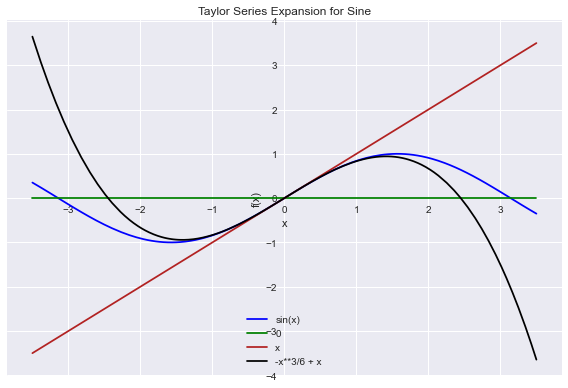

In [7]:
# This will plot sine and its Taylor approximations

p = plot(sin(x), taylor(sin(x),0,1), taylor(sin(x),0,3), taylor(sin(x),0,5), (x,-3.5,3.5), legend=True, show=False)

p[0].line_color = "blue"
p[1].line_color = "green"
p[2].line_color = "firebrick"
p[3].line_color = "black"
p.title = "Taylor Series Expansion for Sine"
p.show()

### Taylor Expansion for Cosine

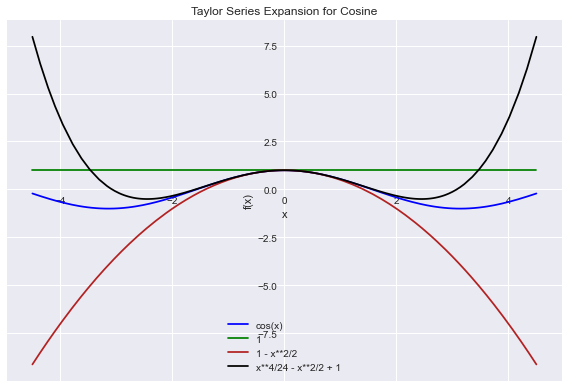

In [8]:
# This will plot cosine and its Taylor approximations

p = plot(cos(x), taylor(cos(x),0,2), taylor(cos(x),0,4), taylor(cos(x),0,6), (x,-4.5,4.5), legend=True, show=False)

p[0].line_color = "blue"
p[1].line_color = "green"
p[2].line_color = "firebrick"
p[3].line_color = "black"
p.title = "Taylor Series Expansion for Cosine"
p.show()

### Taylor Expansion for Exponent

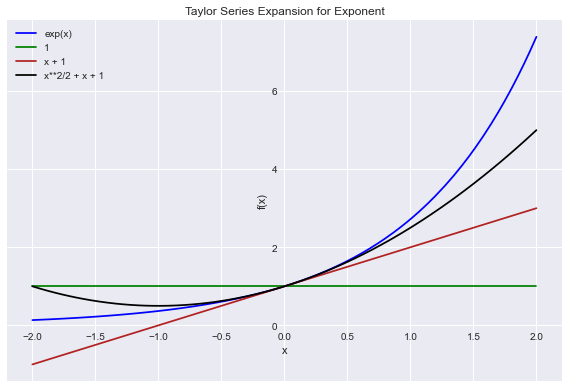

In [9]:
# This will plot exponent and its Taylor approximations

p = plot(exp(x), taylor(exp(x),0,1), taylor(exp(x),0,2), taylor(exp(x),0,3),(x,-2,2), legend=True, show=False)

p[0].line_color = "blue"
p[1].line_color = "green"
p[2].line_color = "firebrick"
p[3].line_color = "black"
p.title = "Taylor Series Expansion for Exponent"
p.show()

## Conclusion

To conclude, in this post we saw how the Taylor series expansion works and coded it in Python. 
Taylor series expansion while approximating a function introduces approximation error. 
The magnitude of error depends on the approximation order. If we increase the order of 
approximation, the error term will decrease, or we can set the tolerance level for error in advance. 
In other words, the error term in approximation can be regarded as $N^{th}$ order **Remainder** term.

For $\mathbb F(x)$ at $x = x_{0} = a$ the remainder term is defined as:

$$
R_{n}(x) =
\mathbb F(x) - P_{n}(x)
$$

Where, $P_{n}(x)$ is the $N^{th}$ order Taylor polynomial for $\mathbb F(x)$ at $x = x_{0} = a$. So,

$$
\mathbb F(x) =
P_{n}(x) + R_{n}(x)
$$

You may wonder why you need Taylor expansion, but it's very important concept in mathematics 
and one of [mathematical beauty](https://en.wikipedia.org/wiki/Mathematical_beauty),
[**Euler's Identity**](https://en.wikipedia.org/wiki/Euler%27s_identity) is derived from Taylor 
series expansion of $cos(x)$, $sin(x)$, and $e(x)$. The derivation of Euler's Identity deserves separate post, 
but if you want to see the derivation, you can take a look at [Khan Academy](https://www.khanacademy.org/math/ap-calculus-bc/bc-series-new/bc-10-14/v/euler-s-formula-and-euler-s-identity). 
Moreover, some training algorithms for neural networks, such as **Steepest Descent**, **Newton's method**, and 
**Conjugate Gradient** uses first or second order Taylor series expansion to minimize performance index.

## References

- [Commonly Used Taylor Series](http://people.math.sc.edu/girardi/m142/handouts/10sTaylorPolySeries.pdf)

- [Wikipedia](https://en.wikipedia.org/wiki/Taylor_series)

- [Khan Academy](https://www.khanacademy.org/math/ap-calculus-bc/bc-series-new/bc-10-11/v/maclaurin-and-taylor-series-intuition)